In [33]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("nykaa_campaign_data.csv")

# Basic Information
print(df.info())
print(df.describe())

# Missing Values
print(df.isnull().sum())

# Remove Duplicates
df.drop_duplicates(inplace=True)

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Derived Features

# Engagement Rate
df['Engagement_Rate'] = (
    df['Clicks'] / df['Impressions']
) * 100

# Conversion Rate
df['Conversion_Rate'] = (
    df['Conversions'] / df['Clicks']
) * 100

# Cost Per Engagement
df['Cost_Per_Engagement'] = (
    df['Acquisition_Cost'] / df['Clicks']
)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

In [3]:
# KPI Calculations

total_campaigns = df['Campaign_ID'].nunique()

total_reach = df['Impressions'].sum()

total_revenue = df['Revenue'].sum()

total_spend = df['Acquisition_Cost'].sum()

avg_engagement = df['Engagement_Rate'].mean()

avg_roi = df['ROI'].mean()

avg_conversion = df['Conversion_Rate'].mean()

avg_cpe = df['Cost_Per_Engagement'].mean()

print("Total Campaigns:", total_campaigns)
print("Total Reach:", total_reach)
print("Total Revenue:", total_revenue)
print("Total Spend:", total_spend)
print("Average Engagement Rate:", avg_engagement)
print("Average ROI:", avg_roi)
print("Average Conversion Rate:", avg_conversion)
print("Average Cost Per Engagement:", avg_cpe)

Total Campaigns: 38350
Total Reach: 2112862530
Total Revenue: 19797269843.0
Total Spend: 14473131.35
Average Engagement Rate: 8.5211614045972
Average ROI: 2.707788265971317
Average Conversion Rate: 21.95345402128302
Average Cost Per Engagement: 0.32335710353103453


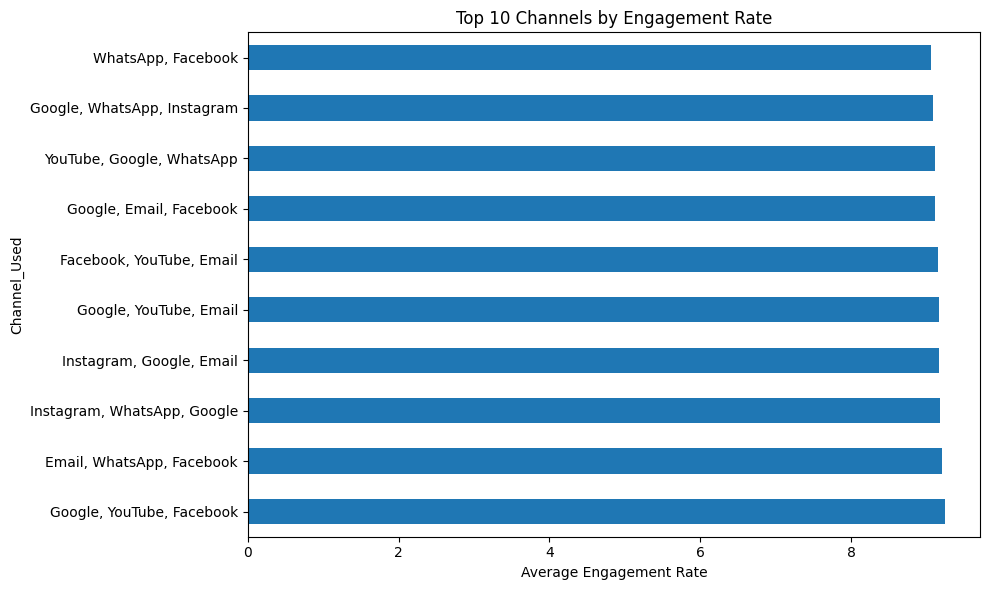

In [16]:

platform_engagement = (
    df.groupby('Channel_Used')['Engagement_Rate']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

platform_engagement.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Channels by Engagement Rate')
plt.xlabel('Average Engagement Rate')
plt.tight_layout()
plt.show()

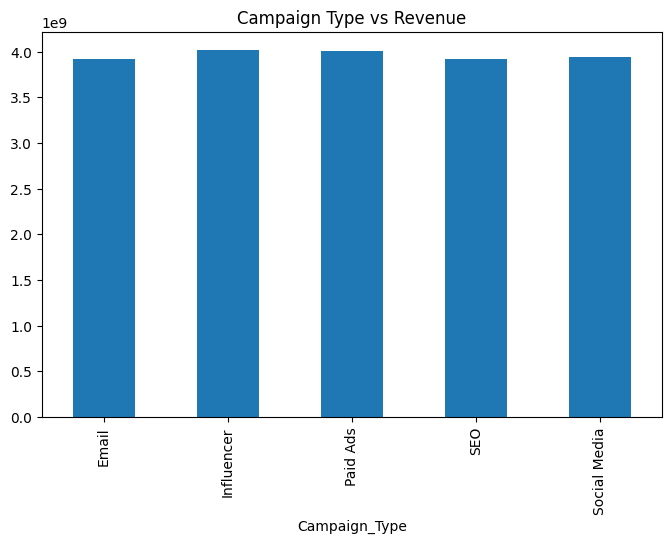

In [5]:
campaign_revenue = df.groupby(
    'Campaign_Type'
)['Revenue'].sum()

campaign_revenue.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Campaign Type vs Revenue")
plt.show()

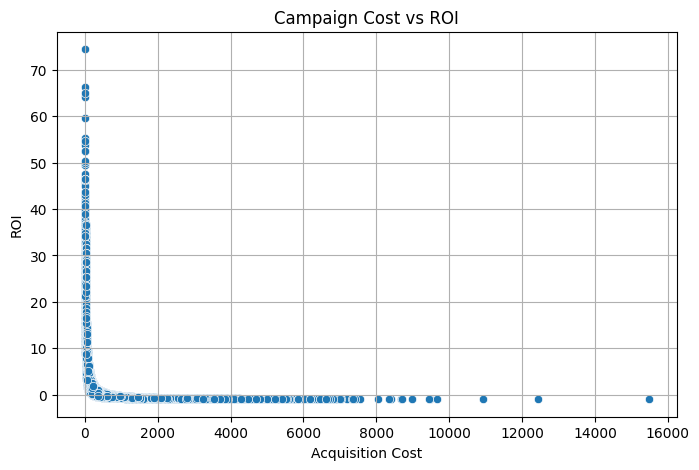

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Acquisition_Cost',
    y='ROI'
)

plt.title("Campaign Cost vs ROI")
plt.xlabel("Acquisition Cost")
plt.ylabel("ROI")
plt.grid(True)

plt.show()

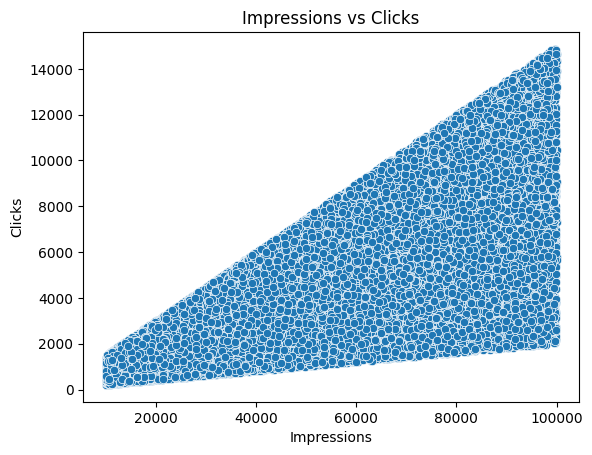

In [7]:
sns.scatterplot(
    data=df,
    x='Impressions',
    y='Clicks'
)

plt.title("Impressions vs Clicks")
plt.show()

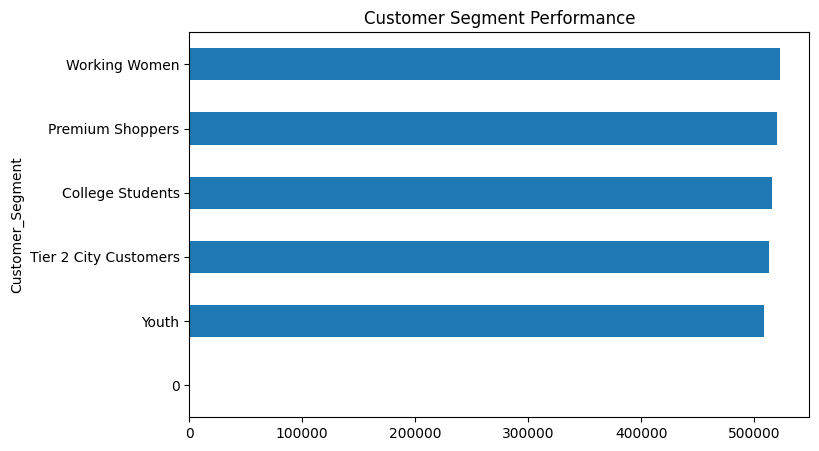

In [8]:
segment_performance = df.groupby(
    'Customer_Segment'
)['Revenue'].mean()

segment_performance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Customer Segment Performance")
plt.show()

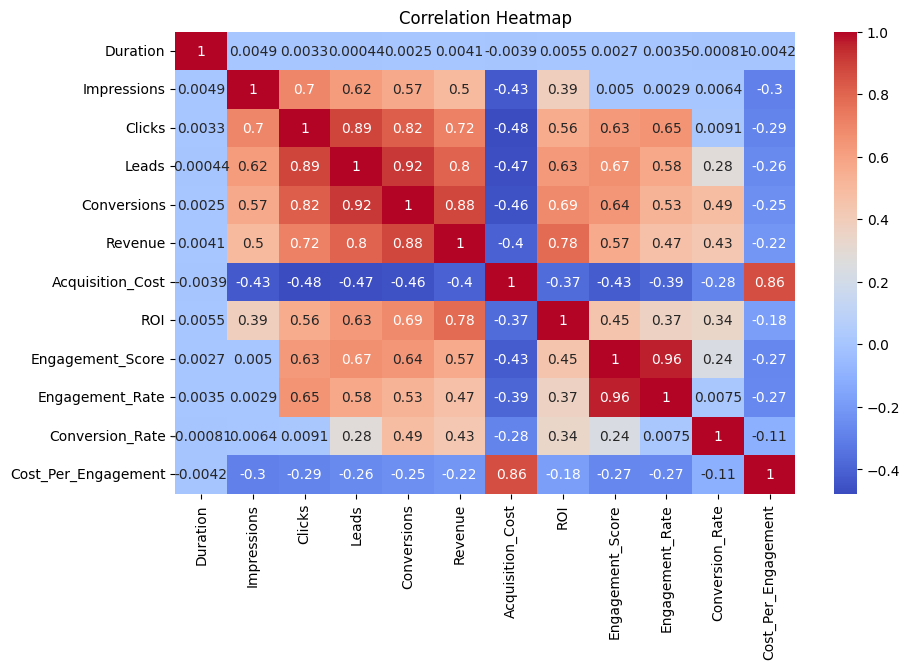

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [10]:
df['ROI_Category'] = pd.cut(
    df['ROI'],
    bins=[-100,0,100,500,1000],
    labels=[
        'Loss',
        'Low ROI',
        'Medium ROI',
        'High ROI'
    ]
)

print(df['ROI_Category'].value_counts())

ROI_Category
Low ROI       29085
Loss           9265
Medium ROI        0
High ROI          0
Name: count, dtype: int64


In [11]:
cost_efficient = df.sort_values(
    by='Cost_Per_Engagement'
).head(10)

print(cost_efficient[
    ['Campaign_ID',
     'Cost_Per_Engagement']
])

        Campaign_ID  Cost_Per_Engagement
38349  NY-CMP-39349             0.000000
12007  NY-CMP-13007             0.000621
2442    NY-CMP-3442             0.000663
4736    NY-CMP-5736             0.000717
10171  NY-CMP-11171             0.000746
21689  NY-CMP-22689             0.000779
25356  NY-CMP-26356             0.000814
227     NY-CMP-1227             0.000825
33619  NY-CMP-34619             0.000883
7098    NY-CMP-8098             0.000939


In [12]:
high_engagement = df[
    df['Engagement_Rate']
    >
    df['Engagement_Rate'].quantile(0.75)
]

print(high_engagement.head())

    Campaign_ID Campaign_Type   Target_Audience  Duration  \
2   NY-CMP-1002    Influencer             Youth        23   
11  NY-CMP-1011           SEO             Youth         7   
19  NY-CMP-1019      Paid Ads  College Students        21   
21  NY-CMP-1021           SEO     Working Women        22   
24  NY-CMP-1024           SEO     Working Women        21   

                  Channel_Used  Impressions  Clicks  Leads  Conversions  \
2    WhatsApp, Google, YouTube        15536    2182    952        755.0   
11           Facebook, YouTube        39696    5623   1136        661.0   
19                   Instagram        55317    7847   1736       1079.0   
21  Instagram, YouTube, Google        27990    3508    761        385.0   
24           YouTube, Facebook        89970   10679   4140       3003.0   

      Revenue  Acquisition_Cost   ROI Language  Engagement_Score  \
2    197055.0             90.60  1.88  English             25.03   
11   286874.0            163.52  1.65    Hindi

In [13]:
dashboard_data = df.copy()

dashboard_data.to_csv(
    "dashboard_dataset.csv",
    index=False
)

print("Dashboard dataset exported.")

Dashboard dataset exported.


In [14]:
# Highest ROI Campaign Type
print(
df.groupby('Campaign_Type')['ROI']
.mean()
.sort_values(ascending=False)
)

# Best Platform
print(
df.groupby('Channel_Used')
['Engagement_Rate']
.mean()
.sort_values(ascending=False)
)

# Best Customer Segment
print(
df.groupby('Customer_Segment')
['Revenue']
.mean()
.sort_values(ascending=False)
)

Campaign_Type
SEO             2.749503
Paid Ads        2.737251
Social Media    2.705477
Influencer      2.685977
Email           2.661377
Name: ROI, dtype: float64
Channel_Used
Google, YouTube, Facebook      9.245963
Email, WhatsApp, Facebook      9.206999
Instagram, WhatsApp, Google    9.183071
Instagram, Google, Email       9.168391
Google, YouTube, Email         9.162211
                                 ...   
Email, YouTube, WhatsApp       7.948287
Email, YouTube, Instagram      7.904213
YouTube, Email, Instagram      7.868754
Facebook, Google, WhatsApp     7.617247
YouTube, Google, Facebook      7.518400
Name: Engagement_Rate, Length: 156, dtype: float64
Customer_Segment
Working Women            522779.122283
Premium Shoppers         520672.084906
College Students         515652.925855
Tier 2 City Customers    513173.990567
Youth                    508967.630755
0                             0.000000
Name: Revenue, dtype: float64
